# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

In [11]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F



%matplotlib inline

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [2]:
from pathlib import Path

In [12]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [13]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [15]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = Path(images_path)
ATTRIBUTES_PATH = Path(attrs_path).joinpath("lfw_attributes.txt")

In [16]:
df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

> Чтение атрибутов для расшифровки

In [17]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids.info())
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обрезка
    # dy - количество пикселей, обрезаемых сверху и снизу
    # dx - количество пикселей, обрезаемых слева и справа
    #
    # Изменение размера
    # dimx - ширина
    # dimy - высота

    images = df['photo_path'].apply(imageio.imread) \
        .apply(lambda img: img[dy:-dy, dx:-dx]) \
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [18]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset(dimx=44, dimy=44)

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms

class NoisyAutoencoderDataset(Dataset):
    def __init__(self, images, indices, noise_factor=0.5, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            noise_factor: коэффициент шума (0-1)
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.noise_factor = noise_factor
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        # Добавляем шум
        noisy_image = image + self.noise_factor * torch.randn_like(image)
        noisy_image = torch.clamp(noisy_image, 0., 1.)

        return noisy_image, image  # Для denoising autoencoder: (noisy, clean)

def get_denoising_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1, noise_factor=0.5):
    """
    Создает DataLoader'ы для denoising autoencoder

        images: numpy array в формате (N, H, W, C)
        noise_factor: коэффициент шума (0-1)
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    train_dataset = NoisyAutoencoderDataset(images, tr, noise_factor=noise_factor, transform=transform)
    val_dataset = NoisyAutoencoderDataset(images, val, noise_factor=noise_factor, transform=transform)
    test_dataset = NoisyAutoencoderDataset(images, ts, noise_factor=noise_factor, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Shuffle=True для обучения
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [29]:
train_loader, val_loader, test_loader = get_denoising_dataloaders(
    images,
    batch_size=32,
    noise_factor=0.1
)

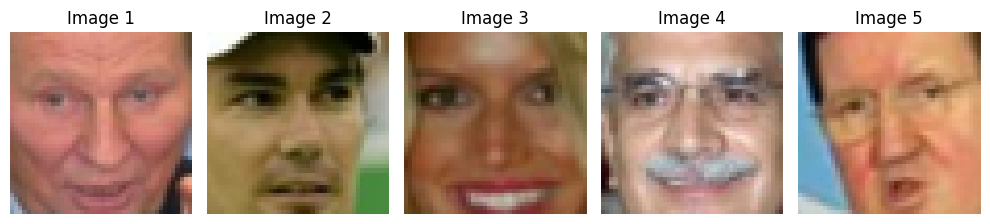

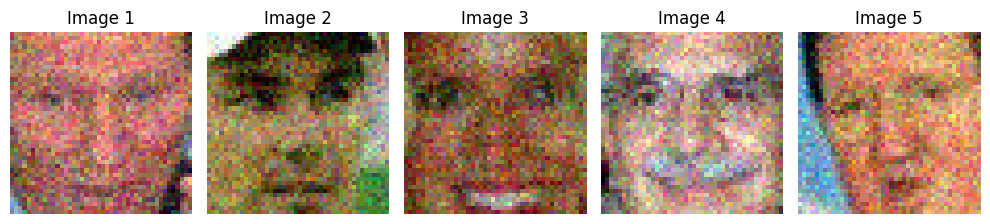

In [38]:
noisy_images, batch_images= next(iter(train_loader))  # Автоэнкодер возвращает (input, target) — берем только input

fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    single_image = batch_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    # Отображаем изображение
    axes[i].imshow(image_np)
    axes[i].axis('off')
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    single_image = noisy_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    axes[i].imshow(image_np)
    axes[i].axis('off')  # Отключаем оси
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()


In [39]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(6*6*64, 128)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 6*6*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 6, 6)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=2),
            nn.AdaptiveAvgPool2d((44, 44)),  # Force the desired output size
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code


In [42]:
from torch import optim


def train_denoising_ae(model, train_loader, val_loader, epochs=50, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for noisy_imgs, clean_imgs in train_loader:
            noisy_imgs = noisy_imgs.to(device)
            clean_imgs = clean_imgs.to(device)

            optimizer.zero_grad()
            outputs, _ = model(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * noisy_imgs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for noisy_imgs, clean_imgs in val_loader:
                noisy_imgs = noisy_imgs.to(device)
                clean_imgs = clean_imgs.to(device)

                outputs, _ = model(noisy_imgs)
                loss = criterion(outputs, clean_imgs)
                val_loss += loss.item() * noisy_imgs.size(0)

        val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')

    return train_losses, val_losses


In [44]:
model = Autoencoder()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_losses, val_losses = train_denoising_ae(model, train_loader, val_loader, epochs=20, device=device)

torch.save(model.state_dict(), 'denoising_autoencoder.pth')

Epoch 1/20 - Train Loss: 0.0192, Val Loss: 0.0091
Epoch 2/20 - Train Loss: 0.0078, Val Loss: 0.0066
Epoch 3/20 - Train Loss: 0.0060, Val Loss: 0.0057
Epoch 4/20 - Train Loss: 0.0052, Val Loss: 0.0049
Epoch 5/20 - Train Loss: 0.0046, Val Loss: 0.0045
Epoch 6/20 - Train Loss: 0.0043, Val Loss: 0.0042
Epoch 7/20 - Train Loss: 0.0040, Val Loss: 0.0039
Epoch 8/20 - Train Loss: 0.0038, Val Loss: 0.0038
Epoch 9/20 - Train Loss: 0.0035, Val Loss: 0.0035
Epoch 10/20 - Train Loss: 0.0034, Val Loss: 0.0035
Epoch 11/20 - Train Loss: 0.0033, Val Loss: 0.0033
Epoch 12/20 - Train Loss: 0.0032, Val Loss: 0.0032
Epoch 13/20 - Train Loss: 0.0031, Val Loss: 0.0031
Epoch 14/20 - Train Loss: 0.0030, Val Loss: 0.0031
Epoch 15/20 - Train Loss: 0.0029, Val Loss: 0.0029
Epoch 16/20 - Train Loss: 0.0028, Val Loss: 0.0028
Epoch 17/20 - Train Loss: 0.0027, Val Loss: 0.0028
Epoch 18/20 - Train Loss: 0.0027, Val Loss: 0.0028
Epoch 19/20 - Train Loss: 0.0026, Val Loss: 0.0027
Epoch 20/20 - Train Loss: 0.0026, Val Lo

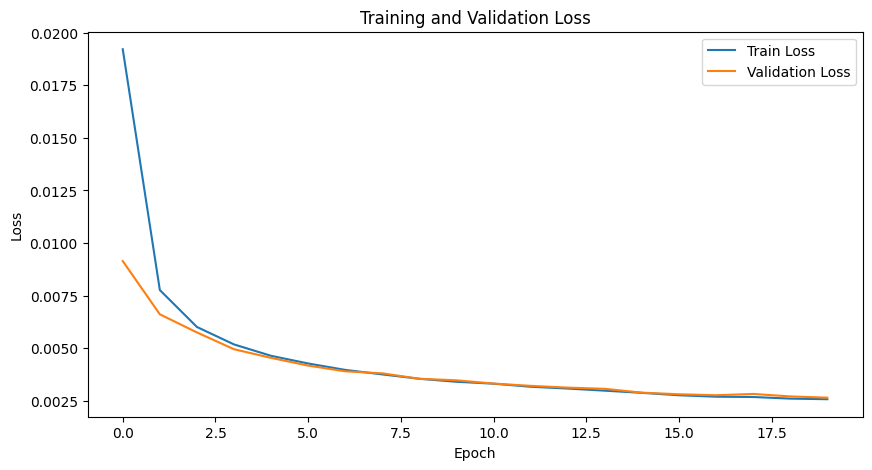

In [47]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

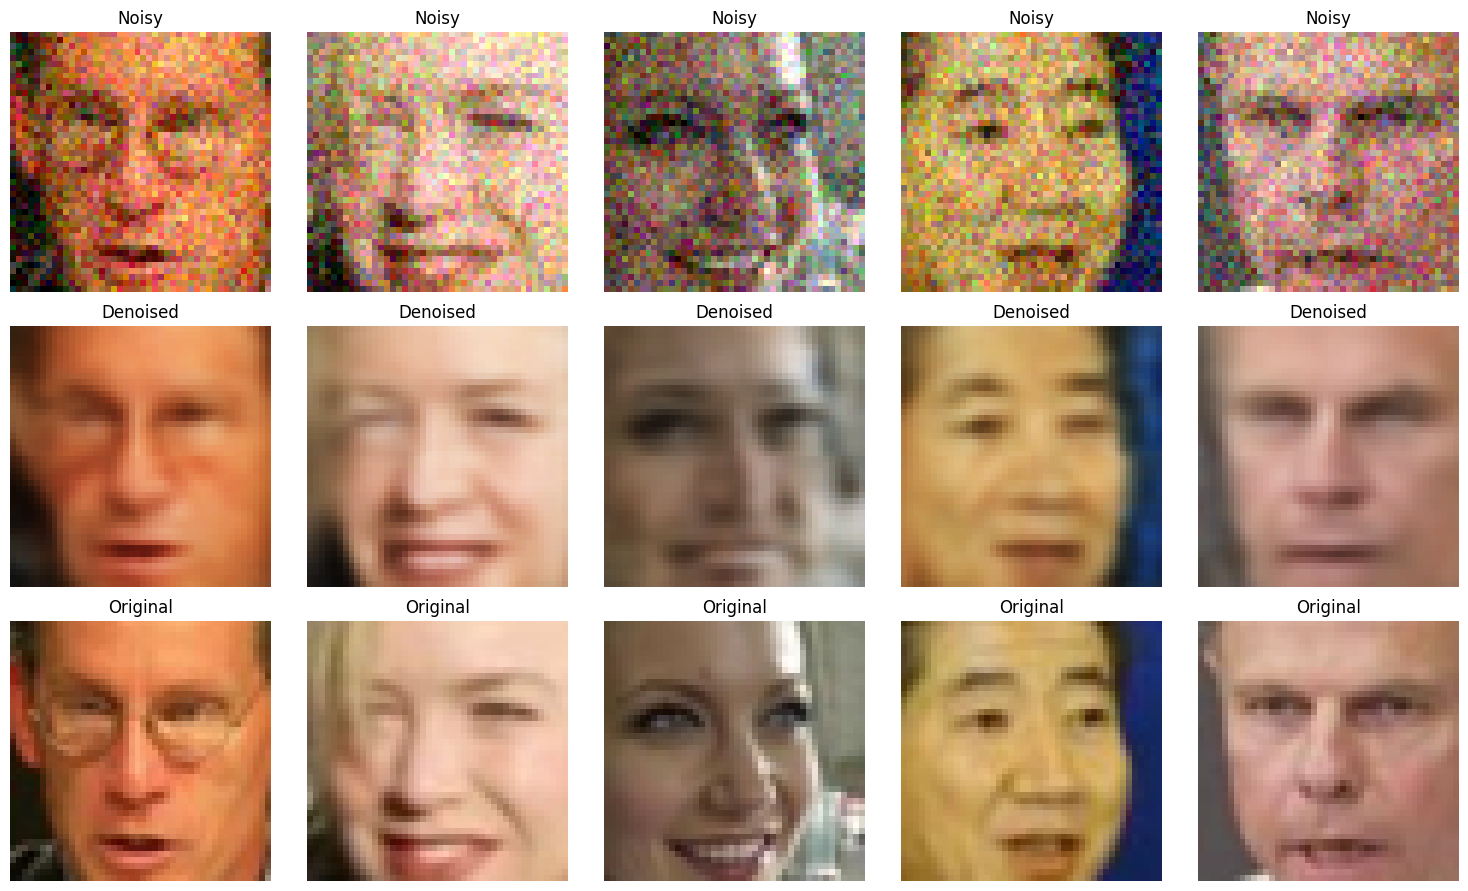

In [48]:
model.eval()
with torch.no_grad():
    # Get a batch of validation data
    noisy_imgs, clean_imgs = next(iter(val_loader))
    noisy_imgs = noisy_imgs.to(device)
    clean_imgs = clean_imgs.to(device)

    # Get model predictions
    denoised_imgs, _ = model(noisy_imgs)

    # Convert to numpy for visualization
    noisy_imgs = noisy_imgs.cpu().numpy()
    clean_imgs = clean_imgs.cpu().numpy()
    denoised_imgs = denoised_imgs.cpu().numpy()

    # Plot some examples
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    for i in range(5):
        axes[0, i].imshow(np.transpose(noisy_imgs[i], (1, 2, 0)))
        axes[0, i].set_title('Noisy')
        axes[0, i].axis('off')

        axes[1, i].imshow(np.transpose(denoised_imgs[i], (1, 2, 0)))
        axes[1, i].set_title('Denoised')
        axes[1, i].axis('off')

        axes[2, i].imshow(np.transpose(clean_imgs[i], (1, 2, 0)))
        axes[2, i].set_title('Original')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()